## Multi Layers Perceptrons

In [1]:
# import the libraies fro multi layer perceptrons
import pandas as pd
import numpy as  np
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

c:\Users\Abu bakar\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 210ms/step - loss: 4.3347 - val_loss: 0.7233
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - loss: 1.6563 - val_loss: 1.5170
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - loss: 1.6687 - val_loss: 0.8142
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 1.3646 - val_loss: 0.6707
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - loss: 1.3425 - val_loss: 0.6733
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - loss: 1.2693 - val_loss: 0.7335
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - loss: 1.3068 - val_loss: 0.8210
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 306ms/step - loss: 1.2453 - val_loss: 0.6476
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 417ms/step - loss: 1.2218 - val_loss: 0.6308
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 510ms/step - loss: 1.1928 - val_loss: 0.6893
dict_keys(['loss', 'val_loss'])
Test Loss (MSE): 0.6893190145492554


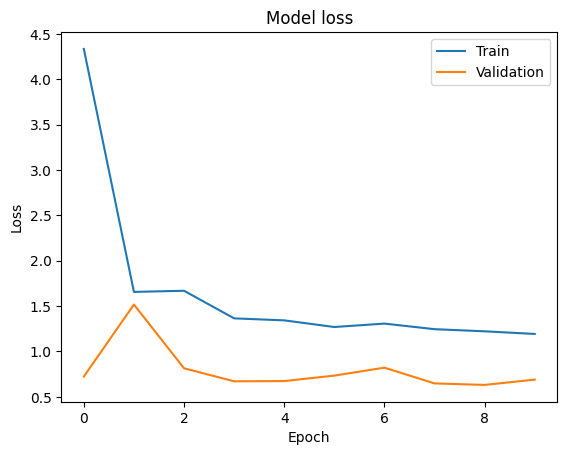

In [2]:
def multi_layer_perceptron(dataset):
    dataset = pd.get_dummies(dataset, drop_first=True)
    X = dataset.drop("tip", axis=1)
    y = dataset['tip']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    input_layer = tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],))
    hidden_layer = tf.keras.layers.Dense(32, activation='relu')
    output_layer = tf.keras.layers.Dense(1)

    model = tf.keras.models.Sequential([input_layer, hidden_layer, output_layer])
    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1, validation_data=(X_test, y_test))
    print(history.history.keys())
    loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss (MSE): {loss}")

    # plot the loss and validation 
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Model loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.show()

    return model

tip = sns.load_dataset("tips")
model = multi_layer_perceptron(tip)

### **Add the layers inside the `tf.keras.models.Sequential` rather then define individually outside**

c:\Users\Abu bakar\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 496ms/step - loss: 1.3750 - val_loss: 0.6149
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 1.2816 - val_loss: 0.7853
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 1.1970 - val_loss: 0.6044
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 1.2581 - val_loss: 0.7174
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step - loss: 1.2223 - val_loss: 0.6530
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 1.2410 - val_loss: 0.7114
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 1.4527 - val_loss: 0.9491
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 1.1423 - val_loss: 0.6320
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 230ms/step - loss: 1.2930 - val_loss: 0.8290
Epoch 10/10
7/7 ━━━━━━

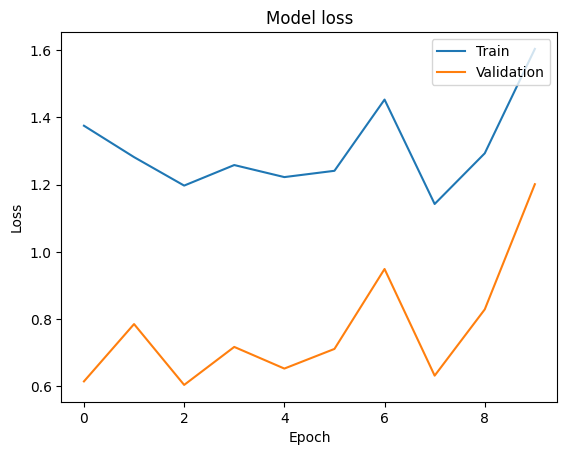

In [3]:
def multi_layer_perceptron(dataset):
    dataset = pd.get_dummies(dataset, drop_first=True)
    X = dataset.drop("tip", axis=1)
    y = dataset['tip']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    input_layer = tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],))
    hidden_layer = tf.keras.layers.Dense(32, activation='relu')
    output_layer = tf.keras.layers.Dense(1)

    model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
        ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1, validation_data=(X_test, y_test))
    print(history.history.keys())
    loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss (MSE): {loss}")

    # plot the loss and validation 
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Model loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.show()

    return model

tip = sns.load_dataset("tips")
model = multi_layer_perceptron(tip)

---

### **Early Stoping of Epochs (Callback Function)**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

def multi_layer_perceptron(dataset):
    dataset = pd.get_dummies(dataset, drop_first=True)
    X = dataset.drop("tip", axis=1)
    y = dataset['tip']

    # split the data into trainning and testing data 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # make an object of the model and add the layers rather than declare seperately
    model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
        ])
    model.compile(optimizer='adam', loss='mean_squared_error')


    # Add a callback function here
    early_stoping = EarlyStopping(patience=5)
    # fit the model and save into the histoy for ploting the losss and epochs
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1, validation_data=(X_test, y_test), callbacks=[early_stoping])
    # evaluate the model 
    loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss (MSE): {loss}")

    # plot the loss and validation 
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Model loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.show()

    return model

# load the dataset 
tip = sns.load_dataset("tips")

# call the function 
model = multi_layer_perceptron(tip)